# Dataset Setup, Frame Extraction & EDA
### Running locally on Windows

## Installing Libraries

In [1]:
import sys

print("Installing libraries...")
print("-" * 60)

!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu -q --user
!{sys.executable} -m pip install albumentations -q --user
!{sys.executable} -m pip install adversarial-robustness-toolbox -q --user
!{sys.executable} -m pip install foolbox -q --user
!{sys.executable} -m pip install grad-cam -q --user
!{sys.executable} -m pip install opencv-python -q --user
!{sys.executable} -m pip install scikit-learn matplotlib seaborn pandas numpy tqdm -q --user
!{sys.executable} -m pip install midv500 requests -q --user

print("-" * 60)
print("Installation complete.")

Installing libraries...
------------------------------------------------------------


------------------------------------------------------------
Installation complete.


## Import Libraries

In [1]:
import os
import cv2
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("All imports successful.")
print(f"OpenCV  : {cv2.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")

All imports successful.
OpenCV  : 5.0.0
NumPy   : 1.24.3
Pandas  : 2.0.3


## Project Configuration

In [2]:
# Project paths
# All data lives inside a single project folder on your C: drive
# Change this path if you want it somewhere else

PROJECT_DIR     = Path(r"C:/adversarial_doc_project")
DATA_DIR        = PROJECT_DIR / "data"
RAW_DIR         = DATA_DIR / "raw"
FRAMES_DIR      = DATA_DIR / "frames"
SPLITS_DIR      = DATA_DIR / "splits"
OUTPUTS_DIR     = PROJECT_DIR / "outputs"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"

# Create all directories
for d in [DATA_DIR, RAW_DIR, FRAMES_DIR, SPLITS_DIR, OUTPUTS_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Frame extraction config 
IMG_SIZE        = 224
FRAMES_PER_CLIP = 10    # 10 frames per clip = ~10,000-30,000 total frames
DEBUG_LIMIT     = None  # Set to 50 to test quickly; None = process everything

CLASS_NAMES = {0: "real", 1: "benign", 2: "malicious"}

print("Configuration ready.")
print(f"Project folder  : {PROJECT_DIR}")
print(f"Raw data folder : {RAW_DIR}")
print(f"Frames folder   : {FRAMES_DIR}")
print(f"Image size      : {IMG_SIZE}x{IMG_SIZE}")
print(f"Frames per clip : {FRAMES_PER_CLIP}")
print()
print("Disk space check:")
import shutil as sh
total, used, free = sh.disk_usage("C:/")
print(f"  Total : {total // (2**30)} GB")
print(f"  Used  : {used  // (2**30)} GB")
print(f"  Free  : {free  // (2**30)} GB")


Configuration ready.
Project folder  : C:\adversarial_doc_project
Raw data folder : C:\adversarial_doc_project\data\raw
Frames folder   : C:\adversarial_doc_project\data\frames
Image size      : 224x224
Frames per clip : 10

Disk space check:
  Total : 475 GB
  Used  : 264 GB
  Free  : 211 GB


## Download MIDV-500 and MIDV-2019


In [3]:
import midv500

# Check if already downloaded
existing = list(RAW_DIR.rglob("*.avi")) + list(RAW_DIR.rglob("*.mp4"))
if len(existing) > 100:
    print(f"Dataset already downloaded — found {len(existing)} video files.")
    print("Skipping download. Move to next cell.")
else:
    print("Starting download of MIDV-500...")
    print("This will take 10-30 minutes. Leave this cell running.")
    print("-" * 60)

    try:
        midv500.download_dataset(
            download_dir=str(RAW_DIR),
            dataset_name="midv500"
        )
        print("MIDV-500 downloaded successfully.")
    except Exception as e:
        print(f"MIDV-500 download error: {e}")

    print()
    print("Starting download of MIDV-2019...")
    try:
        midv500.download_dataset(
            download_dir=str(RAW_DIR),
            dataset_name="midv2019"
        )
        print("MIDV-2019 downloaded successfully.")
    except Exception as e:
        print(f"MIDV-2019 download error: {e}")

    print("-" * 60)
    print("Download phase complete.")

# Verify
all_vids = list(RAW_DIR.rglob("*.avi")) + list(RAW_DIR.rglob("*.mp4"))
print(f"\nTotal video files found: {len(all_vids)}")


Starting download of MIDV-500...
This will take 10-30 minutes. Leave this cell running.
------------------------------------------------------------
--------------------------------------------------------------

Downloading: 01_alb_id.zip


01_alb_id.zip: 657MB [00:25, 26.0MB/s]                                                                                 


Downloaded: 01_alb_id.zip
Unzipping: 01_alb_id.zip
Unzipped: 01_alb_id
--------------------------------------------------------------

Downloading: 02_aut_drvlic_new.zip


02_aut_drvlic_new.zip: 674MB [00:26, 25.4MB/s]                                                                         


Downloaded: 02_aut_drvlic_new.zip
Unzipping: 02_aut_drvlic_new.zip
Unzipped: 02_aut_drvlic_new
--------------------------------------------------------------

Downloading: 03_aut_id_old.zip


...

Downloaded: 48_usa_passportcard.zip
Unzipping: 48_usa_passportcard.zip
Unzipped: 48_usa_passportcard
--------------------------------------------------------------

Downloading: 49_usa_ssn82.zip


49_usa_ssn82.zip: 851MB [00:26, 32.1MB/s]                                                                              


Downloaded: 49_usa_ssn82.zip
Unzipping: 49_usa_ssn82.zip
Unzipped: 49_usa_ssn82
--------------------------------------------------------------

Downloading: 50_xpo_id.zip


50_xpo_id.zip: 786MB [00:27, 29.0MB/s]                                                                                 


Downloaded: 50_xpo_id.zip
Unzipping: 50_xpo_id.zip
Unzipped: 50_xpo_id
MIDV-2019 downloaded successfully.
------------------------------------------------------------
Download phase complete.

Total video files found: 350


## Explore Raw Dataset Structure

In [4]:
# Find all video files
video_extensions = [".avi", ".mp4", ".mov", ".mkv"]
all_videos = []
for ext in video_extensions:
    all_videos.extend(RAW_DIR.rglob(f"*{ext}"))

all_videos = sorted(all_videos)
print(f"Total video clips found: {len(all_videos)}")
print()
print("First 10 clips:")
for v in all_videos[:10]:
    print(f"  {v.relative_to(RAW_DIR)}")

midv500_count = sum(1 for v in all_videos if "midv500" in str(v).lower()
                    or ("2019" not in str(v) and "midv" in str(v).lower()))
midv2019_count = sum(1 for v in all_videos if "2019" in str(v))

print(f"\nMIDV-500  clips: {midv500_count}")
print(f"MIDV-2019 clips: {midv2019_count}")


Total video clips found: 700

First 10 clips:
  midv2019\videos\DG01.mp4
  midv2019\videos\DG02.mp4
  midv2019\videos\DG03.mp4
  midv2019\videos\DG04.mp4
  midv2019\videos\DG05.mp4
  midv2019\videos\DG06.mp4
  midv2019\videos\DG07.mp4
  midv2019\videos\DG08.mp4
  midv2019\videos\DG09.mp4
  midv2019\videos\DG10.mp4

MIDV-500  clips: 500
MIDV-2019 clips: 200


## Extract Frames from Video Clips

In [5]:
def extract_frames_from_video(video_path, output_dir, n_frames=10, img_size=224):
    """
    Extract n_frames evenly-spaced frames from a video.
    Saves as JPG files resized to img_size x img_size.
    Returns number of frames saved.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return 0

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return 0

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    saved = 0
    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.resize(frame, (img_size, img_size))
        cv2.imwrite(str(Path(output_dir) / f"frame_{i:03d}.jpg"), frame)
        saved += 1

    cap.release()
    return saved


# Run extraction
videos_to_process = all_videos
if DEBUG_LIMIT:
    videos_to_process = all_videos[:DEBUG_LIMIT]
    print(f"DEBUG MODE: processing first {DEBUG_LIMIT} clips only")

print(f"Extracting {FRAMES_PER_CLIP} frames from {len(videos_to_process)} clips...")
print(f"Output size per frame: {IMG_SIZE}x{IMG_SIZE}")
print("-" * 60)

total_saved = 0
failed = []
clip_registry = []

for video_path in tqdm(videos_to_process, desc="Extracting"):
    safe_name = str(video_path.relative_to(RAW_DIR)).replace(
        os.sep, "_").replace("/", "_").replace(".", "_")
    out_dir = FRAMES_DIR / safe_name

    n = extract_frames_from_video(video_path, out_dir, FRAMES_PER_CLIP, IMG_SIZE)

    if n > 0:
        total_saved += n
        clip_registry.append({
            "video_path" : str(video_path),
            "clip_name"  : safe_name,
            "frames_dir" : str(out_dir),
            "n_frames"   : n,
            "dataset"    : "midv2019" if "2019" in str(video_path) else "midv500"
        })
    else:
        failed.append(str(video_path))

print("-" * 60)
print(f"Frames saved   : {total_saved}")
print(f"Clips processed: {len(clip_registry)}")
print(f"Failed clips   : {len(failed)}")

registry_path = DATA_DIR / "clip_registry.json"
with open(registry_path, "w") as f:
    json.dump(clip_registry, f, indent=2)
print(f"Registry saved : {registry_path}")


Extracting 10 frames from 700 clips...
Output size per frame: 224x224
------------------------------------------------------------


Extracting: 100%|████████████████████████████████████████████████████████████████████| 700/700 [46:13<00:00,  3.96s/it]

------------------------------------------------------------
Frames saved   : 7000
Clips processed: 700
Failed clips   : 0
Registry saved : C:\adversarial_doc_project\data\clip_registry.json


## Build Frame Index

In [6]:
all_frame_paths   = []
all_frame_datasets = []
all_frame_clips    = []

for clip in clip_registry:
    frames = sorted(Path(clip["frames_dir"]).glob("*.jpg"))
    for fp in frames:
        all_frame_paths.append(str(fp))
        all_frame_datasets.append(clip["dataset"])
        all_frame_clips.append(clip["clip_name"])

df = pd.DataFrame({
    "frame_path" : all_frame_paths,
    "dataset"    : all_frame_datasets,
    "clip_name"  : all_frame_clips,
    "label"      : 0,
    "label_name" : "real"
})

print(f"Total frames indexed: {len(df)}")
print(f"\nDataset breakdown:")
print(df["dataset"].value_counts().to_string())

index_path = DATA_DIR / "frame_index.csv"
df.to_csv(index_path, index=False)
print(f"\nFrame index saved: {index_path}")


Total frames indexed: 7000

Dataset breakdown:
dataset
midv500     5000
midv2019    2000

Frame index saved: C:\adversarial_doc_project\data\frame_index.csv


## Train / Validation / Test Split

In [7]:
unique_clips = df["clip_name"].unique()
print(f"Unique clips: {len(unique_clips)}")

train_clips, temp = train_test_split(unique_clips, test_size=0.30, random_state=SEED)
val_clips, test_clips = train_test_split(temp, test_size=0.50, random_state=SEED)

def get_split(clip):
    if clip in train_clips: return "train"
    if clip in val_clips:   return "val"
    return "test"

df["split"] = df["clip_name"].apply(get_split)

print(f"\nSplit breakdown:")
counts = df["split"].value_counts()
for split in ["train", "val", "test"]:
    n = counts.get(split, 0)
    pct = n / len(df) * 100
    print(f"  {split:<6}: {n:>6} frames ({pct:.1f}%)")

for split in ["train", "val", "test"]:
    path = SPLITS_DIR / f"{split}.csv"
    df[df["split"] == split].to_csv(path, index=False)
    print(f"Saved {split}.csv")

print(f"\nAll splits saved to: {SPLITS_DIR}")


Unique clips: 700

Split breakdown:
  train :   4900 frames (70.0%)
  val   :   1050 frames (15.0%)
  test  :   1050 frames (15.0%)
Saved train.csv
Saved val.csv
Saved test.csv

All splits saved to: C:\adversarial_doc_project\data\splits


## Exploratory Data Analysis

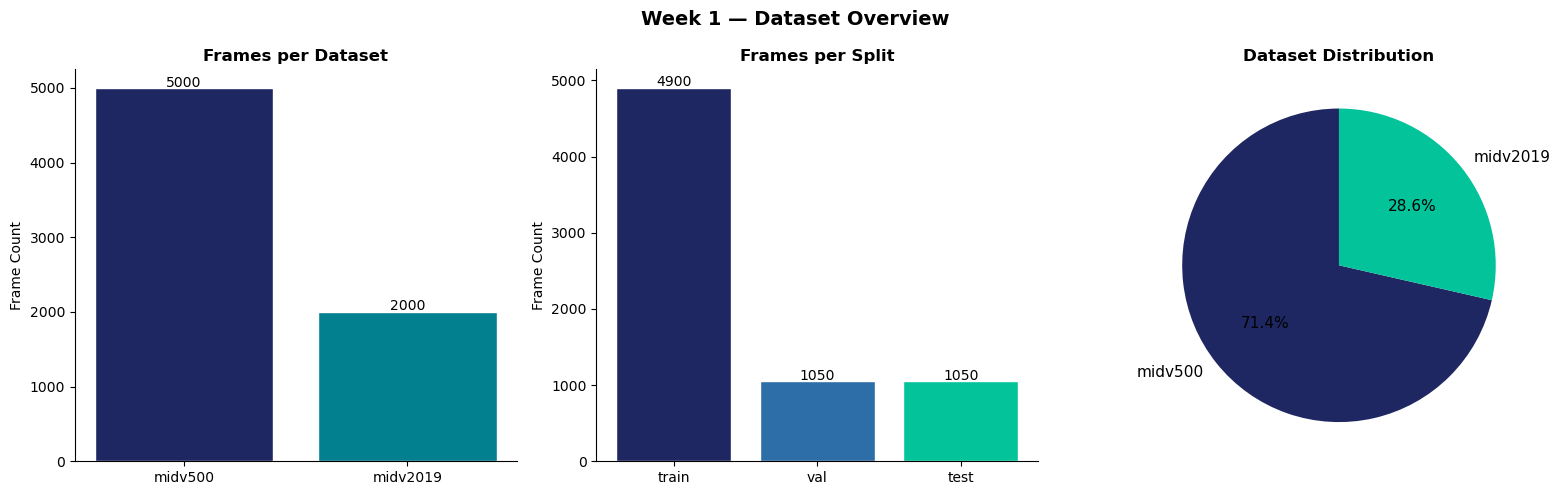

Plot saved: C:\adversarial_doc_project\outputs\week1_dataset_overview.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Week 1 — Dataset Overview", fontsize=14, fontweight="bold")

# Plot 1: Frames per dataset
ax = axes[0]
ds_counts = df["dataset"].value_counts()
bars = ax.bar(ds_counts.index, ds_counts.values,
              color=["#1E2761", "#028090"], edgecolor="white")
ax.set_title("Frames per Dataset", fontweight="bold")
ax.set_ylabel("Frame Count")
for b, v in zip(bars, ds_counts.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
            str(v), ha="center", fontsize=10)
ax.spines[["top","right"]].set_visible(False)

# Plot 2: Frames per split
ax = axes[1]
split_order = ["train", "val", "test"]
split_vals  = [counts.get(s, 0) for s in split_order]
bars2 = ax.bar(split_order, split_vals,
               color=["#1E2761", "#2D6EA8", "#02C39A"], edgecolor="white")
ax.set_title("Frames per Split", fontweight="bold")
ax.set_ylabel("Frame Count")
for b, v in zip(bars2, split_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
            str(v), ha="center", fontsize=10)
ax.spines[["top","right"]].set_visible(False)

# Plot 3: Dataset pie
ax = axes[2]
ax.pie(ds_counts.values, labels=ds_counts.index,
       colors=["#1E2761", "#02C39A"],
       autopct="%1.1f%%", startangle=90,
       textprops={"fontsize": 11})
ax.set_title("Dataset Distribution", fontweight="bold")

plt.tight_layout()
out = OUTPUTS_DIR / "week1_dataset_overview.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved: {out}")


## Visualise Sample Frames

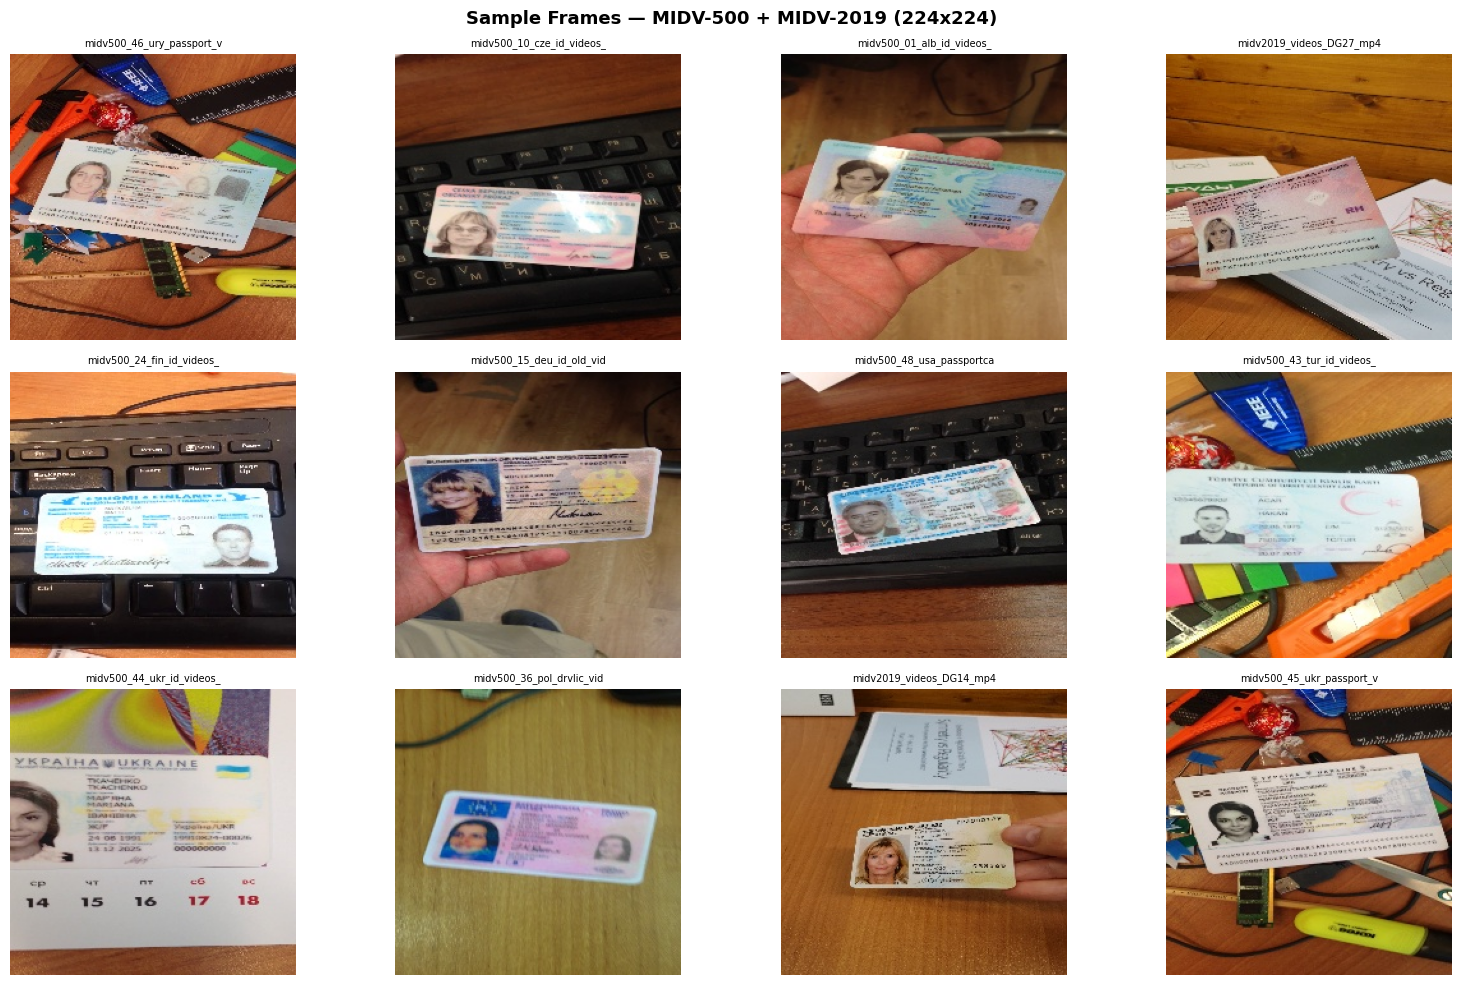

Sample frames saved: C:\adversarial_doc_project\outputs\week1_sample_frames.png


In [9]:
sample_paths = df["frame_path"].sample(12, random_state=SEED).tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle("Sample Frames — MIDV-500 + MIDV-2019 (224x224)",
             fontsize=13, fontweight="bold")

for ax, path in zip(axes.flatten(), sample_paths):
    img = cv2.imread(path)
    if img is None:
        ax.axis("off")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(Path(path).parent.name[:25], fontsize=7)
    ax.axis("off")

plt.tight_layout()
out = OUTPUTS_DIR / "week1_sample_frames.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Sample frames saved: {out}")


## Verify Image Dimensions

In [10]:
sample_check = df["frame_path"].sample(min(100, len(df)), random_state=SEED).tolist()
sizes = []
for path in sample_check:
    img = cv2.imread(path)
    if img is not None:
        h, w, c = img.shape
        sizes.append((h, w))

unique_sizes = set(sizes)
print(f"Unique dimensions in sample: {unique_sizes}")

if unique_sizes == {(IMG_SIZE, IMG_SIZE)}:
    print(f"All frames correctly sized at {IMG_SIZE}x{IMG_SIZE}.")
else:
    print("WARNING: unexpected sizes found. Check extraction.")


Unique dimensions in sample: {(224, 224)}
All frames correctly sized at 224x224.
